In [1]:
import json
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import statsmodels.api as sm
from odrpack import odr_fit
import random
from sklearn import metrics
from sklearn.cluster import MeanShift
import statistics
import sqlite3
import pandas
import requests
from astropy.io import fits

In [2]:
with open('data/grb_analysis.json', 'r') as file:
    data = json.load(file)

In [3]:
with open('data/lat_error_plot.json', 'r') as file:
    lat_err = json.load(file)

In [4]:
r = requests.get("https://icecube.wisc.edu/~grbweb_public/GRBweb2.sqlite")
f = open('GRBweb2.sqlite', 'wb').write(r.content)

In [5]:
db = sqlite3.connect('GRBweb2.sqlite')

In [6]:
H_naught_mpc = 67.66
H_err = 0.42
Lambda_m = 0.3103
m_err = 0.0057
Lambda_G = 0.6897
G_err = 0.0057
Lambda_k = 0.685
conversion= 3.08567758128*10**19
H_naught = H_naught_mpc/conversion

In [7]:
def f(t):
    num = np.float128((1+t))
    den = np.float128((Lambda_m*(1+t)**3)+Lambda_G)
    return num/(np.sqrt(den))

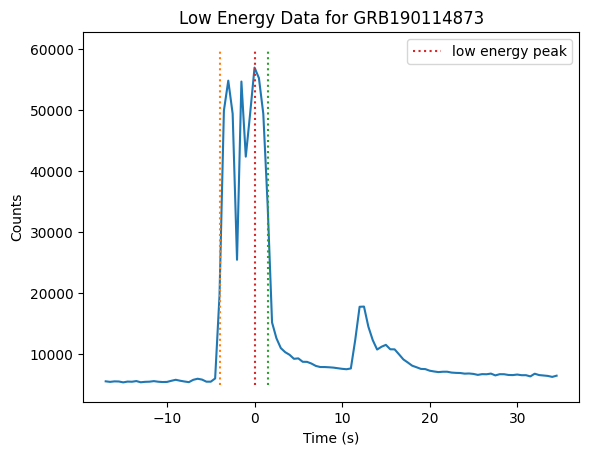

<Figure size 640x480 with 0 Axes>

In [8]:
event_list = ["190114873","221009553","080916406"]
event = event_list[0]

low_lim = 250
high_lim = 680
X_prime = data[event]["time_values"][low_lim:(len(data[event]["time_values"])-high_lim)]
X = [[x_c[0] - data[event]["low_t"]] for x_c in X_prime]
Y = data[event]["time_array"][low_lim:(len(data[event]["time_array"])-high_lim)]
plt.plot(X, Y)

low_half = 0
high_half = 0
for i in range(len(Y)):
    if Y[i] > 0.5*data[event]["low_ct"]:
        low_half = X[i-1][0]
        high_half = low_half+data[event]["half_max_t"]
        break

x = [5000,60000]
low_y= [low_half,low_half]
high_y= [high_half,high_half]
mid_y= [0,0]
plt.plot(low_y,x,linestyle = 'dotted')
plt.plot(high_y,x,linestyle = 'dotted')
plt.plot(mid_y,x,label='low energy peak',linestyle = 'dotted')

plt.title("Low Energy Data for GRB" + event)
plt.xlabel("Time (s)")
plt.ylabel("Counts")
plt.legend()
plt.show()
plt.savefig("GRB"+event+".png")

In [151]:
def getLATPLOT_II(event, fov):
    time_window = 300
    e_low = 2000

    grbwb_name = "GRB" + str(event)
    Sum_table = pandas.read_sql_query("SELECT * from Summary", db)
    Sum_table = Sum_table.sort_values("GRB_name_Fermi")
    indices = np.where(Sum_table == grbwb_name)
    row_indices, col_indices = indices[0], indices[1]
    index = Sum_table.iloc[row_indices].to_numpy()[0][0] - 1
    web_r = Sum_table.iloc[row_indices].ra.get(index)
    web_d = Sum_table.iloc[row_indices].decl.get(index)

    data[event]["lat_highs"]
    w = []
    for i in data[event]["lat_highs"]:
        r = float(i["RA"]) - web_r
        r = (r + 180) % 360 - 180
        d = float(i["DEC"]) - web_d
        d = (d + 180) % 360 - 180
        w.append(np.sqrt(r**2+d**2))
        
    x = [float(i["Max Time"]) - data[event]["low_t"] for i in data[event]["lat_highs"]]
    y = [float(i["Max Energy"]) for i in data[event]["lat_highs"]]
    
    X = []
    Y = []
    Z = []
    High_y = [0]
    High_x = [0]
    for i in range(len(y)):
        E = y[i]
        z = float(data[event]["redshift"])
        K_int = sp.integrate.quad(f, 0, z)[0]
        K = float(1/(H_naught))*float((E)/(1+z))*float(K_int)
        E=(K/(3*10**21))
        time_window = 300 + data[event]["half_max_t"]*5 #+ E *(1+float(data[event]["redshift"]))
        #time_window = 300
        #print(time_window)
        
        if x[i] < time_window and x[i] > -time_window:
            if w[i] < fov:
                if y[i] > e_low:
                    X.append(x[i])
                    Y.append(y[i])
                    Z.append([x[i],0])
                    if 0 == High_y[0]:
                        High_x[0] = x[i]
                        High_y[0] = y[i]
                    elif y[i] > 2500* y[i] *(1+float(data[event]["redshift"])):
                        High_x.append(x[i])
                        High_y.append(y[i])
                        
    if High_y[0] == 0:
        return [0,0]
                    
    #plt.scatter(X,Y,s=10)
    #plt.xlim(-1200, 1200)
    #plt.title("High Energy Data for GRB" + event)
    #plt.xlabel("Time (s)")
    #plt.ylabel("Energy (MeV)")
    #plt.savefig("LAT_fig/LAT"+ event + "COEF" + str(coef) +".png")
    #plt.show()
    #plt.close()
    return [High_x, High_y]

In [152]:
big_list = {}
for i in range(len(list(data.items()))):
    event = list(data.items())[i][0]
    result = getLATPLOT_II(event, 10)
    big_list[event] = result

In [153]:
def get_lat_err(E):
    for i in range(len(lat_err)):
        if E < float(lat_err[i]['x']):
            diff = float(lat_err[i]['y']) - float(lat_err[i-1]['y'])
            scale = (E-float(lat_err[i-1]['x']))/(float(lat_err[i]['x'])-float(lat_err[i-1]['x']))
            #print(diff)
            #print(scale)
            err = diff*scale + float(lat_err[i-1]['y'])
            return err

In [154]:
def eIG(t):
    num = np.float128((1+t))
    den = np.float128((Lambda_m*(1+t)**3)+Lambda_G)
    return num/((np.sqrt(den))**3)

In [155]:
def eIm(t):
    num = np.float128((1+t)**4)
    den = np.float128((Lambda_m*(1+t)**3)+Lambda_G)
    return num/((np.sqrt(den))**3)

In [156]:
def eK(K, E, z):
    error = -1
    H_e = (H_err/H_naught_mpc)**2
    E_e = (get_lat_err(E)/E)**2
    Ig_e = (sp.integrate.quad(eIG, 0, z)[0])**2
    Im_e = (sp.integrate.quad(eIm, 0, z)[0])**2
    error = K*np.sqrt(H_e+E_e+G_err*Ig_e+m_err*Im_e)
    return error

In [162]:
t_list = []
e_list = []
z_list = []
s_list = []
w_list = []
t_err_list = []
error_list = [] #[et, eK]
points_vals = {}
for n in data:
    #print("Checking " + n)
    fail = True
    if data[n]["half_max_t"] > 10*(1+float(data[n]["redshift"])): #1
        continue
    if data[n]["significance"] < 5: #12
        continue
    #s_list = (data[n]["significance"]**8)/50000
    if big_list[n] != [0,0]:
        points_vals[n] = {"times": [], "energy": [], "redshift": float(data[n]["redshift"])}
        for l in range(len(big_list[n][0])):
            time = (big_list[n][0][l])/(1+float(data[n]["redshift"]))
            t_list.append(time)
            points_vals[n]["times"].append(time)
            t_err_list.append(np.sqrt((data[n]["half_max_t"])**2)+((0.0001)**2))
            e_list.append(big_list[n][1][l])
            points_vals[n]["energy"].append(big_list[n][1][l])
            z_list.append(float(data[n]["redshift"]))
            w_list.append(data[n]["half_max_t"]/data[n]["significance"])
            #print("GRB " + str(n) + " has energy " + str(max_E) + " at time " + str((big_cluster_set[n][i][0])/(1+float(data[n]["redshift"]))))

count = 0
for i in points_vals:
    #print(str(i) +" z- "+ str(points_vals[i]["redshift"]))
    for j in range(len(points_vals[i]["times"])):
        #print(str(i) +" t- "+ str(points_vals[i]["times"][j]))
        #print(str(i) +" e- "+ str(points_vals[i]["energy"][j]))
        count = count + 1

print("Total of %s events." % count)

Total of 35 events.


In [163]:
k_list = []
k_err_list = []
for i in range(len(e_list)):
    E = e_list[i]
    z = z_list[i]
    t = t_list[i]
    K_int = sp.integrate.quad(f, 0, z)[0]
    K = float(1/(H_naught))*float((E)/(1+z))*float(K_int)
    k_err_list.append(eK(K, E, z))
    k_list.append(K)

print(len(k_list))

35


In [164]:
def curve_fit_func_intrinsic(x, a, b):
    # Curve fitting function
    return a * x + b  # d=0 is implied

In [165]:
X = k_list
Y = t_list

# Calculate weights based on the inverse of the variance of the errors
errors_times = []
for i in range(len(t_list)):
    tot = (t_list[i])/k_list[i]
    t_e = (t_err_list[i]/(t_list[i]*(1+z_list[i])))**2
    k_e = (k_err_list[i]/k_list[i])**2
    tot_e = tot*np.sqrt(t_e+k_e)
    #errors_times.append(1/tot_e**2)
    errors_times.append(1/tot_e**0.2)
    #errors.append(0.1)

errors_plus = []
for i in range(len(t_list)):
    tot = t_list[i]+k_list[i]
    t_e = (t_err_list[i])**2
    k_e = (k_err_list[i])**2
    tot_e = np.sqrt(t_e+k_e)
    errors_plus.append(1/tot_e**2)
    #errors.append(0.1)

params = curve_fit(curve_fit_func_intrinsic, X, Y)
fit_zero = params[0]
print("===========| " + str(fit_zero[0]) + " |===========")
print(params)

weight_x = k_err_list
weight_y = t_err_list
beta0 = [1.45002541*10**(-19)]

#fit_odr = odr_fit(curve_fit_func_intrinsic, X, Y, beta0, weight_x=weight_x, weight_y=weight_y)
#print("===========| " + str(fit_odr.beta[0]) + " |===========")
#fit_odr = fit_odr.beta[0]

#fit = np.polyfit(X, Y, 1, w=errors_times,full=True)
# Fit weighted least squares regression model
#X = sm.add_constant(X)
#model = sm.WLS(y, X, weights=weights)
#results = model.fit()
#results.summary()
#fit

===========| -2.5045183681795058e-21 |===========
(array([-2.50451837e-21,  4.35649152e+01]), array([[ 8.71504121e-42, -3.71606944e-20],
       [-3.71606944e-20,  3.65911683e+02]]))


/tmp/ipykernel_1351226/3924873581.py:12: RuntimeWarning: invalid value encountered in scalar power
  errors_times.append(1/tot_e**0.2)


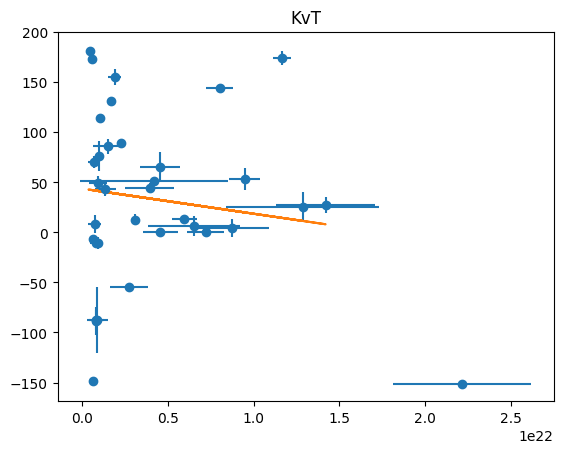

In [166]:
plt.title("KvT")
plt.scatter(k_list,t_list,s=1)
plt.errorbar(k_list,t_list, yerr=t_err_list, xerr=k_err_list, fmt="o")
plot_k = []
plot_t = []
fit_val = params[0][0]
fit_intercept = params[0][1]
k_top = 0.55*(10**22)
plot_t.append(fit_val*k_top+fit_intercept)
plot_k.append(k_top)
for val_k in k_over:
    #plot_t.append(fit[0][1] - fit[0][0]*val_k)
    if fit_val*val_k < 6910:
        plot_t.append(fit_val*val_k+fit_intercept)
        plot_k.append(val_k)
plt.plot(plot_k,plot_t)
plt.show()

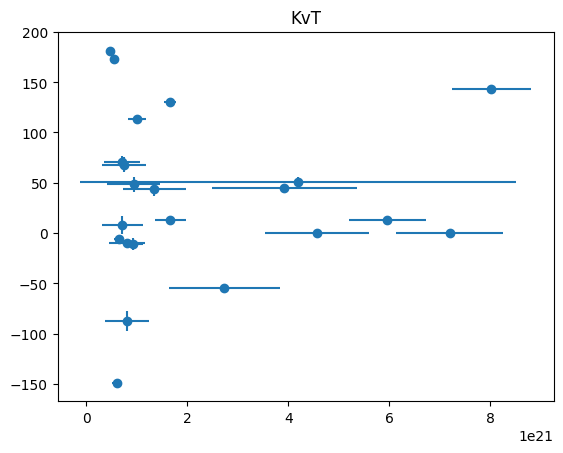

In [146]:
plt.title("KvT")
plt.scatter(k_list,t_list,s=1)
plt.errorbar(k_list,t_list, yerr=t_err_list, xerr=k_err_list, fmt="o")
plt.show()

In [147]:
#number of events
len(k_list)

22

In [148]:
#Scale of Lorentz Invarriance Violation
E_lv = 1/fit_val
print(E_lv)

4.61861020653727e+20


In [149]:
# Percent of Energy above 0 time delay.
test = 0
tot = 0
for i in range(len(t_list)):
    tot = tot + k_list[i]
    if t_list[i] > 0:
        test = test + k_list[i]
print(str(test/tot))

0.8698359272735879


In [150]:
# Percent of Events above 0 time delay
test = 0
tot = 0
for i in range(len(t_list)):
    tot = tot + 1
    if t_list[i] > 0:
        test = test + 1
print(str(test/tot))

0.7272727272727273


In [37]:
k_over = []
k_over_e = []
t_over = []
t_over_e = []
z_over = []
for i in range(len(t_list)):
    if t_list[i] > 0:
        k_over.append(k_list[i])
        t_over.append(t_list[i])
        k_over_e.append(k_err_list[i])
        t_over_e.append(t_err_list[i])
        z_over.append(z_list[i])

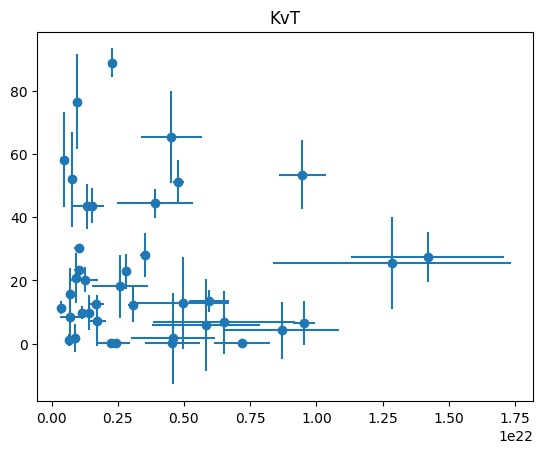

In [38]:
plt.title("KvT")
plt.scatter(k_over,t_over,s=0.1)
plt.errorbar(k_over,t_over, xerr=k_over_e, yerr=t_over_e, fmt="o")
plt.show()

In [39]:
def curve_fit_func(x, a):
    # Curve fitting function
    return a * x  # d=0 is implied

In [42]:
def fit_func(x, beta):
    # Curve fitting function
    a = beta[0]
    return a * x  # d=0 is implied

In [43]:
X = k_over
Y = t_over

# Calculate weights based on the inverse of the variance of the errors
errors_times = []
for i in range(len(t_over)):
    tot = (t_over[i])/k_over[i]
    t_e = (t_over_e[i]/(t_over[i]*(1+z_over[i])))**2
    k_e = (k_over_e[i]/k_over[i])**2
    tot_e = tot*np.sqrt(t_e+k_e)
    #errors_times.append(1/tot_e**2)
    errors_times.append(1/tot_e**0.2)
    #errors.append(0.1)

errors_plus = []
for i in range(len(t_over)):
    tot = t_over[i]+k_over[i]
    t_e = (t_over_e[i])**2
    k_e = (k_over_e[i])**2
    tot_e = np.sqrt(t_e+k_e)
    errors_plus.append(1/tot_e**2)
    #errors.append(0.1)


params = curve_fit(curve_fit_func, X, Y)
fit_zero = params[0]
print("===========| " + str(fit_zero[0]) + " |===========")

weight_x = k_over_e
weight_y = t_over_e
beta0 = [1.45002541*10**(-19)]

fit_odr = odr_fit(fit_func, X, Y, beta0, weight_x=weight_x, weight_y=weight_y)
print("===========| " + str(fit_odr.beta[0]) + " |===========")
fit_odr = fit_odr.beta[0]

fit = np.polyfit(X, Y, 1, w=errors_times,full=True)
# Fit weighted least squares regression model
#X = sm.add_constant(X)
#model = sm.WLS(y, X, weights=weights)
#results = model.fit()
#results.summary()
fit

===========| 3.2102533216865645e-21 |===========
===========| 3.2712686386598808e-21 |===========


(array([-1.29983403e-22,  1.71945301e+01]),
 array([3.91211927e+12]),
 np.int32(2),
 array([1.34147545, 0.4477093 ]),
 np.float64(8.881784197001252e-15))

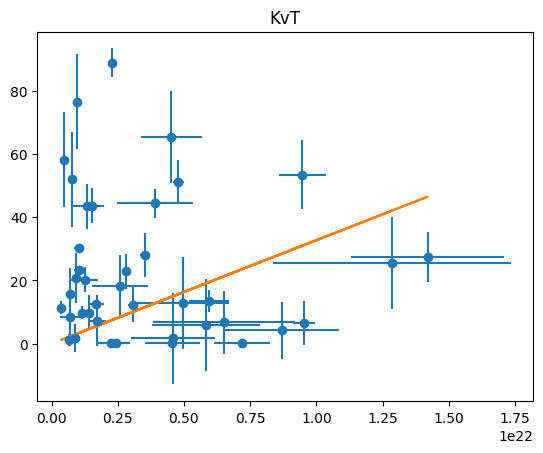

In [44]:
plt.title("KvT")
plt.scatter(k_over,t_over,s=0.1)
plt.errorbar(k_over,t_over, xerr=k_over_e, yerr=t_over_e, fmt="o")
plot_k = []
plot_t = []
k_top = 0.55*(10**22)
plot_t.append(fit_odr*k_top)
plot_k.append(k_top)
for val_k in k_over:
    #plot_t.append(fit[0][1] - fit[0][0]*val_k)
    if fit_odr*val_k < 6910:
        plot_t.append(fit_odr*val_k)
        plot_k.append(val_k)
plt.plot(plot_k,plot_t)
plt.show()